In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [6]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [7]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [8]:
X = df[['MedInc']]

In [9]:
y = df['MedHouseVal']

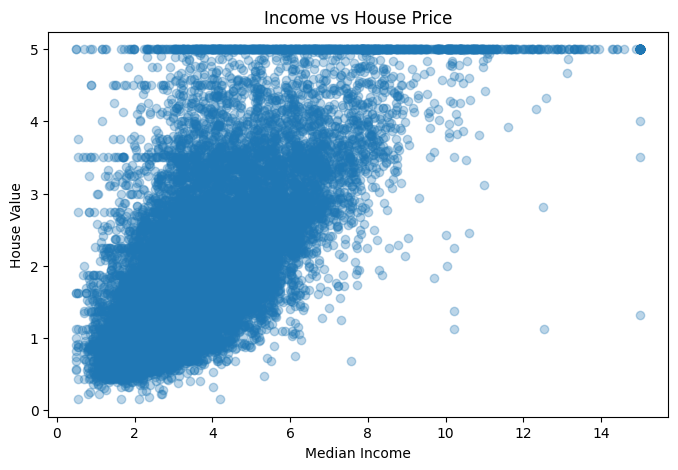

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    alpha=0.3
)

plt.xlabel("Median Income")

plt.ylabel("House Value")

plt.title("Income vs House Price")

plt.show()

In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [13]:
print(model.coef_)

[0.41933849]


In [14]:
print(model.intercept_)

0.4445972916907879


In [16]:
y_pred = model.predict(X_test)

In [17]:
print(y_pred[:10])

[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318 2.42165249
 2.57647226 1.99229181 2.45893168 3.84677436]


In [18]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print(mae)

0.629908653009376


In [19]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print(mse)

0.7091157771765549


In [20]:
import numpy as np

rmse = np.sqrt(mse)

print(rmse)

0.8420901241414455


In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print(r2)

0.45885918903846656


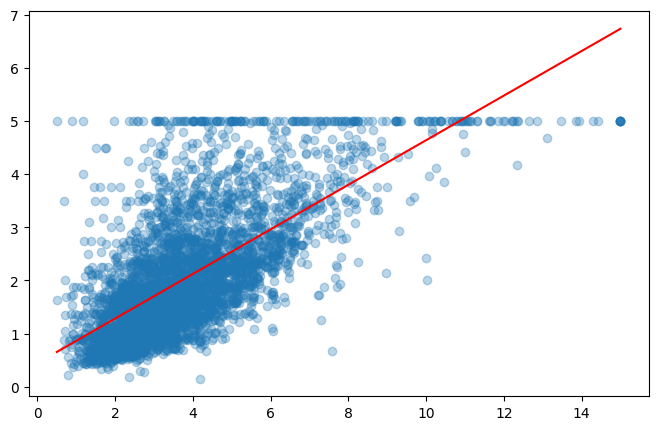

In [22]:
sorted_idx = X_test['MedInc'].argsort()

plt.figure(figsize=(8,5))

plt.scatter(
    X_test,
    y_test,
    alpha=0.3
)

plt.plot(
    X_test.iloc[sorted_idx],
    y_pred[sorted_idx],
    color='red'
)

plt.show()